Recording Ground Truth and Track Trajectory

2026-05-24 11:12:35.244040: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-24 11:12:35.255361: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779592355.269203   21289 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779592355.273339   21289 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-24 11:12:35.287808: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

saved


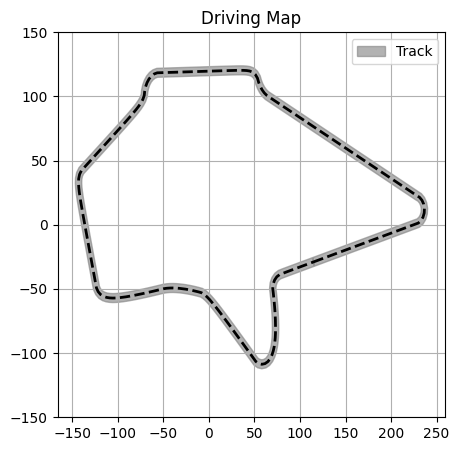

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.atari_wrappers import WarpFrame
from stable_baselines3.common.vec_env import VecFrameStack, VecTransposeImage, VecMonitor

STEPS = 900
MODEL_NAME = "Ground_Truth"
WEIGHTS_DIR = 'closed_loop_weights'
TRACK_DIR = 'tracks'

os.makedirs(TRACK_DIR, exist_ok=True)

env = make_vec_env("CarRacing-v3", n_envs=1, wrapper_class=WarpFrame, env_kwargs={"continuous": True})
env = VecMonitor(env)
env = VecFrameStack(env, n_stack=4)
env = VecTransposeImage(env)
env.seed(42)
obs = env.reset()

#model loading
model = PPO.load(f"{WEIGHTS_DIR}/ppo_continuous.zip")

trajectory_x, trajectory_y, actions = [], [], []

for _ in range(STEPS):
    action, _ = model.predict(obs)
    obs, reward, dones, info = env.step(action)

    car = env.get_attr("car")[0]
    pos = car.hull.position

    trajectory_x.append(float(pos.x))
    trajectory_y.append(float(pos.y))

    actions.append(float(action[0][0]))   # continuous action is array [steer, gas, brake]


track = env.get_attr("track")[0]
center_x = np.array([tile[2] for tile in track])
center_y = np.array([tile[3] for tile in track])

center_x = np.append(center_x, center_x[0])
center_y = np.append(center_y, center_y[0])

dx = np.gradient(center_x)
dy = np.gradient(center_y)

length = np.sqrt(dx**2 + dy**2)
length = np.maximum(length, 1e-8)  

dx /= length
dy /= length

nx = -dy
ny = dx

track_width = 7

left_x = center_x + nx * track_width / 2
left_y = center_y + ny * track_width / 2

right_x = center_x - nx * track_width / 2
right_y = center_y - ny * track_width / 2

env.close()

max_len = max(len(center_x),len(trajectory_x))

def pad(arr, length):
    arr = np.array(arr)
    if len(arr) < length:
        return np.pad(arr, (0, length - len(arr)), constant_values=np.nan)
    return arr[:length]

df = pd.DataFrame({
    "step": np.arange(max_len),

    "center_x": pad(center_x, max_len),
    "center_y": pad(center_y, max_len),

    "left_x": pad(left_x, max_len),
    "left_y": pad(left_y, max_len),

    "right_x": pad(right_x, max_len),
    "right_y": pad(right_y, max_len),

    f"{MODEL_NAME}_x": pad(trajectory_x, max_len),
    f"{MODEL_NAME}_y": pad(trajectory_y, max_len),

    f"{MODEL_NAME}_action": pad(actions, max_len),
})

df.to_csv(f"{TRACK_DIR}/record_{MODEL_NAME}.csv", index=False)
print('saved')

plt.figure(figsize=(5, 5))

plt.fill(
    np.concatenate([left_x, right_x[::-1]]),
    np.concatenate([left_y, right_y[::-1]]),
    color='gray',
    alpha=0.6,
    label="Track"
)

plt.plot(center_x, center_y, '--', color='black', linewidth=2)
# plt.plot(trajectory_x, trajectory_y, 'r', linewidth=2, label="Ground Truth")
plt.ylim(-150, 150)
plt.grid(True)
plt.legend()
plt.title("Driving Map")
plt.show()



2026-05-18 17:06:47.551988: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-18 17:06:47.564586: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779095207.578768   32448 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779095207.582987   32448 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-18 17:06:47.597558: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Running: NSAC


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'ou_wrap', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
I0000 00:00:1779095211.945710   32448 service.cc:148] XLA service 0xe8c11e0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779095211.945743   32448 service.cc:156]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1779095211.949999   32448 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


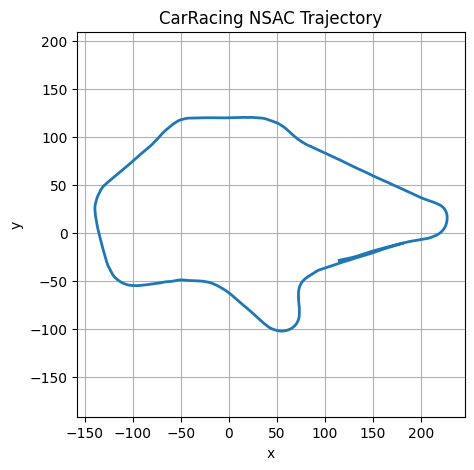

Running: Gaussian-MLE


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 48 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


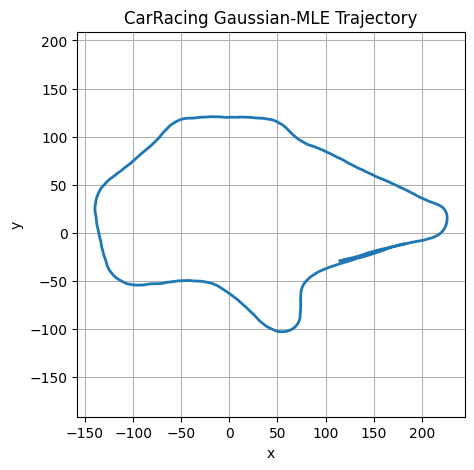

Running: Deep-Ensemble


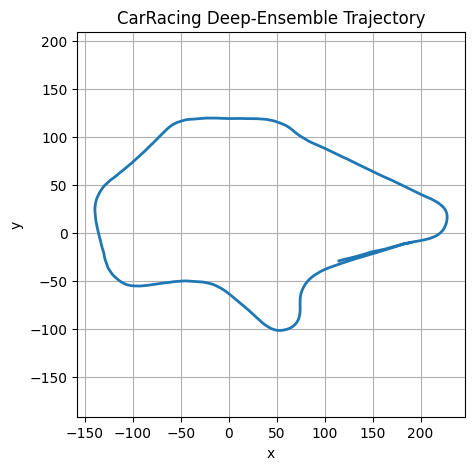

Running: MC-Dropout
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2

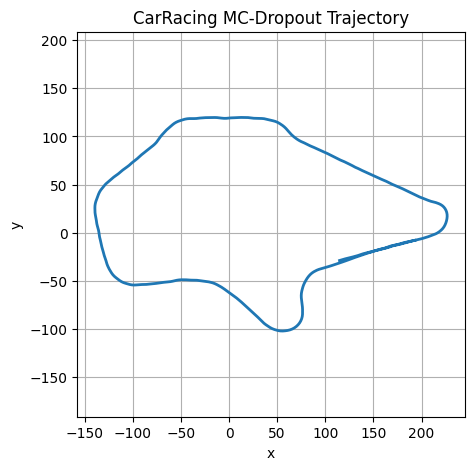

Running: Evidential


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 90 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


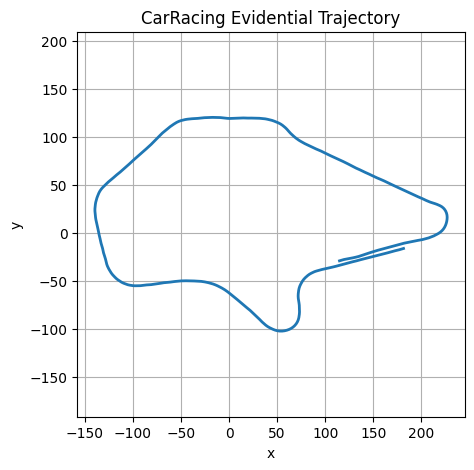

Running: SDE-Net


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━

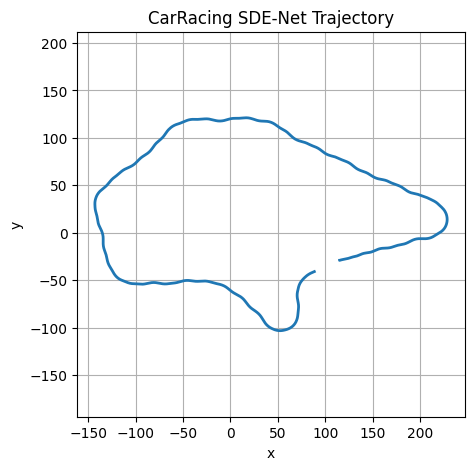

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Flatten, TimeDistributed, Conv2D, GlobalMaxPooling1D, BatchNormalization, MaxPool2D
from tensorflow.keras.models import Model

from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.atari_wrappers import WarpFrame
from stable_baselines3.common.vec_env import VecFrameStack, VecTransposeImage, VecMonitor
import tensorflow as tf
from baseline_cells import ContiFormer, ODEformer, OTTransformer
from neuronal_attention_circuit import NAC
from ouwrap import OUWrap

from ouwrap import OUWrap
from losses import NSACLoss, NLL
from neuronal_attention_circuit import NAC
from neuronal_stochastic_attention_circuit import NSAC
from metrics import compute_crps, compute_ece, compute_auroc



from baselines import DeepEnsemble, MC_dropout, Evidential, GMLE, SDE_Net
from evidential_deep_learning.layers import DenseNormalGamma
from evidential_deep_learning.losses import EvidentialRegression


STEPS = 900
MODEL_NAME = 'CarRacing'
WEIGHTS_DIR = 'closed_loop_weights'
STAT_DIR = 'statistics'
TRACK_DIR = "tracks"
os.makedirs(TRACK_DIR, exist_ok=True)


def preprocess(obs):
    obs = np.transpose(obs, (0, 2, 3, 1))
    obs = np.expand_dims(obs,axis=0)
    obs = obs.astype("float32") / 255.0
    return obs


# Model building functions
def _build_nsac():
    def model_fn(input_shape=(None, 84, 84, 1)):
        inp = Input(shape=input_shape)

        x = TimeDistributed(Conv2D(32,(5,5),activation='relu',strides=3))(inp)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(48,(3,3),activation='relu',strides=2))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(64,(2,2),activation='relu'))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(BatchNormalization())(x)
        x = TimeDistributed(Flatten())(x)
        mu,log_std = OUWrap(
            NAC(d_model=64,num_heads=16, sparsity=0.7, topk=8),
            bn_mean=0.0,
            bn_std=0.0001,
            output_dim=3,
            activation='tanh',
            return_sequences=False
            )(x)
        return Model(inp, [mu,log_std])
    model = NSAC(stochastic_model_fn=model_fn(),mc_samples=3, ood_mean=0.0, ood_std=0.0001)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3), loss=NSACLoss())
    return model

def _build_mle():
    def model_fn(input_shape=(None, 84, 84, 1)):
        inp = Input(shape=input_shape)
        x = TimeDistributed(Conv2D(32,(5,5),activation='relu',strides=3))(inp)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(48,(3,3),activation='relu',strides=2))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(64,(2,2),activation='relu'))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(BatchNormalization())(x)
        x = TimeDistributed(Flatten())(x)
        x = NAC(
            d_model=64,
            num_heads=16,
            mode='exact',
            sparsity=0.5,
            topk=16,
            activation='relu',
            return_sequences=False
        )(x)
        mu = tf.keras.layers.Dense(3)(x)
        log_std = tf.keras.layers.Dense(3)(x)
        return tf.keras.Model(inp, [mu,log_std])
    model = GMLE(model_fn())
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3), loss=NLL())
    return model

def _build_deep_ensemble():
    def model_fn(input_shape=(None, 84, 84, 1)):
        inp = Input(shape=input_shape)
        x = TimeDistributed(Conv2D(32,(5,5),activation='relu',strides=3))(inp)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(48,(3,3),activation='relu',strides=2))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(64,(2,2),activation='relu'))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(BatchNormalization())(x)
        x = TimeDistributed(Flatten())(x)
        x = NAC(
            d_model=64,
            num_heads=16,
            mode='exact',
            sparsity=0.5,
            topk=16,
            activation='relu',
            return_sequences=False
        )(x)
        mu = tf.keras.layers.Dense(3)(x)
        log_std = tf.keras.layers.Dense(3)(x)
        return tf.keras.Model(inp, [mu,log_std])
    model = DeepEnsemble(model_fn=model_fn(), num_models=3)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3), loss=NLL())
    return model

def _build_mc_dropout():
    def model_fn(input_shape=(None, 84, 84, 1),dropout_rate=0.1):
        inp = Input(shape=input_shape)
        x = TimeDistributed(Conv2D(32,(5,5),activation='relu',strides=3))(inp)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(48,(3,3),activation='relu',strides=2))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(64,(2,2),activation='relu'))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(BatchNormalization())(x)
        x = TimeDistributed(Flatten())(x)
        x = NAC(
            d_model=64,
            num_heads=16,
            mode='exact',
            sparsity=0.5,
            topk=16,
            activation='relu',
            return_sequences=False
        )(x)
        mu = tf.keras.layers.Dense(3)(x)
        log_std = tf.keras.layers.Dense(3)(x)
        return tf.keras.Model(inp, [mu,log_std])
    model = MC_dropout(model_fn=model_fn(),mc_samples=5)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3), loss=NLL())
    return model

def _build_evidential():
    def model_fn(input_shape=(None, 84, 84, 1)):
        inp = Input(shape=input_shape)
        x = TimeDistributed(Conv2D(32,(5,5),activation='relu',strides=3))(inp)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(48,(3,3),activation='relu',strides=2))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(64,(2,2),activation='relu'))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(BatchNormalization())(x)
        x = TimeDistributed(Flatten())(x)
        x = NAC(
            d_model=64,
            num_heads=16,
            mode='exact',
            sparsity=0.5,
            topk=16,
            activation='relu',
            return_sequences=False
        )(x)
        output = DenseNormalGamma(3)(x)
        return tf.keras.Model(inp, output)
    model = Evidential(model_fn(),lambda_reg=0.5)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3), loss=EvidentialRegression)
    return model

class CNN_SDE_Wrapper(tf.keras.Model):
    def __init__(self, sde_net: SDE_Net):
        super().__init__()
        self.cnn = self._build_cnn()
        self.sde_net = sde_net
        self.optimizer_cnn = tf.keras.optimizers.AdamW(1e-3)
        self.mc_samples = 10

    def _build_cnn(self):
        return tf.keras.Sequential([
            TimeDistributed(Conv2D(32, (5,5), activation='relu', strides=3)),
            TimeDistributed(MaxPool2D(2, 2)),
            TimeDistributed(Conv2D(48, (3,3), activation='relu', strides=2)),
            TimeDistributed(MaxPool2D(2, 2)),
            TimeDistributed(Conv2D(64, (2,2), activation='relu')),
            TimeDistributed(MaxPool2D(2, 2)),
            TimeDistributed(BatchNormalization()),
            TimeDistributed(Flatten()),
        ])

    def _cnn_to_sde(self, x, training_diffusion=False):
        features = self.cnn(x)                      
        shape    = tf.shape(features)
        flat     = tf.reshape(features, (shape[0] * shape[1], features.shape[-1]))
        return self.sde_net(flat, training_diffusion=training_diffusion)

    def call(self, inputs, training_diffusion=False):
        return self._cnn_to_sde(inputs, training_diffusion)
    
    def compile(self, optimizer_drift, optimizer_fc, optimizer_dsl, optimizer_diffusion, loss, **kwargs):
        super().compile(**kwargs)  
        self.sde_net.compile(
            optimizer_drift=optimizer_drift,
            optimizer_fc=optimizer_fc,
            optimizer_dsl=optimizer_dsl,
            optimizer_diffusion=optimizer_diffusion,
            loss=loss,
        )

    def train_step(self, data):
        x, y = data
        x = tf.cast(x, tf.float32)
        y = tf.cast(y, tf.float32)
        with tf.GradientTape() as tape:
            features  = self.cnn(x, training=True)   
            last_feat = features[:, -1, :]
            mean, sigma = self.sde_net(last_feat, training_diffusion=False)
            nll = self.sde_net.loss_fn(y, [mean, sigma])

        cnn_grad = [tf.clip_by_norm(g, 100)
                    for g in tape.gradient(nll, self.cnn.trainable_variables)]
        self.optimizer_cnn.apply_gradients(zip(cnn_grad, self.cnn.trainable_variables))
        last_feat_detached = tf.stop_gradient(features[:, -1, :])
        sde_metrics = self.sde_net.train_step((last_feat_detached, y))
        return sde_metrics

    def test_step(self, data):
        x, y      = data
        features  = self.cnn(tf.cast(x, tf.float32), training=False)
        last_feat = features[:, -1, :]
        return self.sde_net.test_step((last_feat, tf.cast(y, tf.float32)))
    
    def calculate_uncertainty(self, X):
        X = tf.cast(X, tf.float32)
        means, variances = [], []

        for _ in range(self.mc_samples):
            mean, sigma = self.call(X, training_diffusion=False)
            means.append(mean.numpy())
            variances.append((sigma ** 2).numpy())

        means = np.stack(means, axis=0)         # [T, N, 1]
        variances = np.stack(variances, axis=0)         # [T, N, 1]

        mean_pred = np.mean(means, axis=0)
        epistemic_unc = np.var(means, axis=0)
        aleatoric_unc = np.mean(variances, axis=0)
        total_uncertainty = epistemic_unc + aleatoric_unc

        return mean_pred, aleatoric_unc, epistemic_unc, total_uncertainty

    def predict_with_uncertainty(self, X):
        mean_pred, aleatoric, epistemic, _ = self.calculate_uncertainty(X)
        return mean_pred, aleatoric, epistemic

    def comprehensive_evaluate(self, X_test, y_test):
        X_test = tf.cast(X_test, tf.float32)
        y_test = tf.cast(y_test, tf.float32)

        mean_pred, aleatoric, epistemic, total_uncertainty = self.calculate_uncertainty(X_test)
        seq_len = X_test.shape[1]
        mean_pred_last = mean_pred[seq_len-1::seq_len]  # shape [batch, output_dim]

        variance = tf.clip_by_value(total_uncertainty, 1e-6, 1e6)
        variance = variance[seq_len-1::seq_len]  # shape [batch, output_dim]

        results = super().evaluate(
            X_test,
            y_test,
            return_dict=True,
            verbose=0
        )
        nll = float(results["loss"])
        mse = tf.reduce_mean(tf.square(y_test - mean_pred_last))
        predictive_std = tf.sqrt(variance)

        return (mean_pred_last, predictive_std.numpy(), nll, mse.numpy())

    def get_config(self):
        config = super().get_config()
        config.update({
            "sde_net": self.sde_net.get_config(),
        })
        return config
    def from_config(cls, config):
        model = tf.keras.utils.deserialize_keras_object(config.pop("model"))
        return cls(model_fn=model, **config)
    

def _build_sde_net():
    sde = SDE_Net(input_dim=64, output_dim=3, hidden_dim=32, layer_depth=5)
    model = CNN_SDE_Wrapper(sde)

    model.compile(
        optimizer_drift=tf.keras.optimizers.AdamW(1e-3),
        optimizer_fc=tf.keras.optimizers.AdamW(1e-3),
        optimizer_dsl=tf.keras.optimizers.AdamW(1e-3),
        optimizer_diffusion=tf.keras.optimizers.AdamW(1e-4),
        loss=NLL(),
    )
    dummy_input = tf.zeros((1, 1, 84, 84, 1))  
    _ = model(dummy_input, training_diffusion=False)
    return model

MODEL_LIST = [
    "NSAC",
    "Gaussian-MLE",
    "Deep-Ensemble",
    "MC-Dropout",
    "Evidential",
    "SDE-Net",
]

for name in MODEL_LIST:
    # env.render()
    print(f"Running: {name}")

    env = make_vec_env("CarRacing-v3",n_envs=1, wrapper_class=WarpFrame, env_kwargs={"continuous": True})
    env = VecMonitor(env)
    env = VecFrameStack(env, n_stack=4)
    env = VecTransposeImage(env)
    env.seed(42)
    obs = env.reset()

    if name == "NSAC":
        model = _build_nsac()
    elif name == "Gaussian-MLE":
        model = _build_mle()
    elif name == "Deep-Ensemble":
        model = _build_deep_ensemble()
    elif name == "MC-Dropout":
        model = _build_mc_dropout()
    elif name == "Evidential":
        model = _build_evidential()
    elif name == "SDE-Net":
        model = _build_sde_net()
    else: 
        pass

    model.load_weights(f"{WEIGHTS_DIR}/{MODEL_NAME}_{name}.keras")


    trajectory_x, trajectory_y, actions = [], [], []

    for _ in range(STEPS):
        processed_obs = preprocess(obs)

        pred, _ = model.predict(processed_obs)
        action = pred[0].copy()

        action[0] = np.clip(action[0], -1, 1)
        action[1] = np.clip(action[1], 0, 1)
        action[2] = np.clip(action[2], 0, 1)
        action = action.reshape(1, -1)
        obs, _, dones, _ = env.step(action)
        
        car = env.get_attr("car")[0]
        pos = car.hull.position

        trajectory_x.append(float(pos.x))
        trajectory_y.append(float(pos.y))
        actions.append(action[0][0])

    env.close()

    df = pd.DataFrame({
        "step": np.arange(len(trajectory_x)),
        f"{name}_x": trajectory_x,
        f"{name}_y": trajectory_y,
        f"{name}_action": actions,
    })

    df.to_csv(f"{TRACK_DIR}/record_{name}.csv", index=False)

    plt.figure(figsize=(5,5))
    plt.plot(trajectory_x, trajectory_y, linewidth=2)
    plt.title(f"CarRacing {name} Trajectory")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.grid(True)
    plt.show()



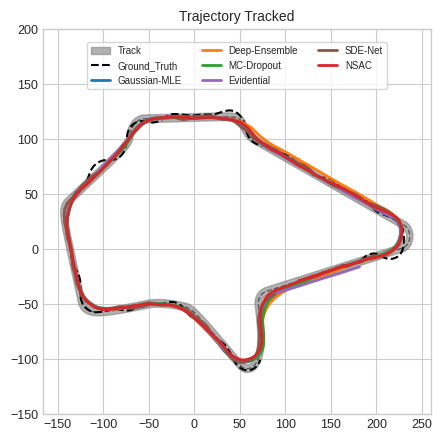

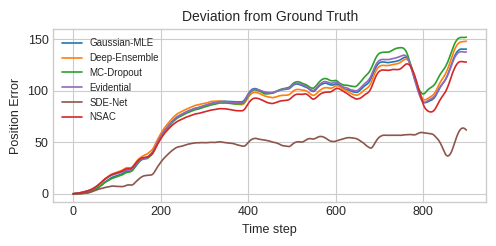

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


TRACK_DIR = "tracks"
os.makedirs(TRACK_DIR, exist_ok=True)


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
})

MODEL_LIST = ["Ground_Truth", "Gaussian-MLE", "Deep-Ensemble", "MC-Dropout", "Evidential", "SDE-Net", "NSAC"]

COLOR_MAP = {
    "Ground_Truth": "black",
    "Gaussian-MLE": "tab:blue",
    "Deep-Ensemble": "tab:orange",
    "MC-Dropout": "tab:green",
    "Evidential": "tab:purple",
    "SDE-Net": "tab:brown",
    "NSAC": "tab:red",
}


# -------------------- TRACK --------------------
def extract_track(df):
    required = ["center_x", "center_y", "left_x", "left_y", "right_x", "right_y"]

    if not all(col in df.columns for col in required):
        return None

    return {
        "center_x": df["center_x"].values,
        "center_y": df["center_y"].values,
        "left_x": df["left_x"].values,
        "left_y": df["left_y"].values,
        "right_x": df["right_x"].values,
        "right_y": df["right_y"].values,
    }


# -------------------- TRAJECTORY --------------------
def extract_trajectory(df, x_col, y_col, label):
    if df is None:
        return None

    if x_col not in df.columns or y_col not in df.columns:
        return None

    return {
        "x": df[x_col].values,
        "y": df[y_col].values,
        "label": label
    }


def plot_error(trajectories):
    gt = next((t for t in trajectories if t["label"] == "Ground_Truth"), None)

    if gt is None:
        raise ValueError("Ground_Truth trajectory not found.")

    plt.figure(figsize=(5, 2.5))

    for traj in trajectories:
        if traj["label"] == "Ground_Truth":
            continue

        n = min(len(gt["x"]), len(traj["x"]))

        error = np.sqrt(
            (traj["x"][:n] - gt["x"][:n])**2 +
            (traj["y"][:n] - gt["y"][:n])**2
        )

        color = COLOR_MAP.get(traj["label"], None)
        plt.plot(error, label=traj["label"], color=color)

    plt.title("Deviation from Ground Truth")
    plt.xlabel("Time step")
    plt.ylabel("Position Error")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_scene(track, trajectories):
    if track is None:
        raise ValueError("Track data not found.")

    plt.figure(figsize=(5, 5))

    # track boundary
    plt.fill(
        np.concatenate([track["left_x"], track["right_x"][::-1]]),
        np.concatenate([track["left_y"], track["right_y"][::-1]]),
        color="gray",
        alpha=0.6,
        label="Track"
    )

    plt.plot(
        track["center_x"],
        track["center_y"],
        "--",
        color="black",
        linewidth=1,
        alpha=0.5
    )

    # trajectories
    for traj in trajectories:
        color = COLOR_MAP.get(traj["label"], None)

        if traj["label"] == "Ground_Truth":
            plt.plot(
                traj["x"], traj["y"],
                linestyle="--",
                linewidth=1.5,
                color=color,
                label=traj["label"]
            )
        else:
            plt.plot(
                traj["x"], traj["y"],
                linewidth=2,
                color=color,
                label=traj["label"]
            )

    plt.ylim(-150, 200)
    plt.grid(True)
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        ncol=3,   # adjust based on how many items you usually have
        frameon=True,
    )
    plt.title("Trajectory Tracked")
    # plt.tight_layout()
    plt.show()


trajectories = []
track = None

for name in MODEL_LIST:
    file_path = f"{TRACK_DIR}/record_{name}.csv"

    if not os.path.exists(file_path):
        print(f"Warning: missing file {file_path}, skipping.")
        continue

    df = pd.read_csv(file_path)

    if name == "Ground_Truth":
        track = extract_track(df)

    traj = extract_trajectory(df, f"{name}_x", f"{name}_y", name)

    if traj is not None:
        trajectories.append(traj)


# -------------------- PLOT --------------------
plot_scene(track, trajectories)
plot_error(trajectories)

Heatmaps

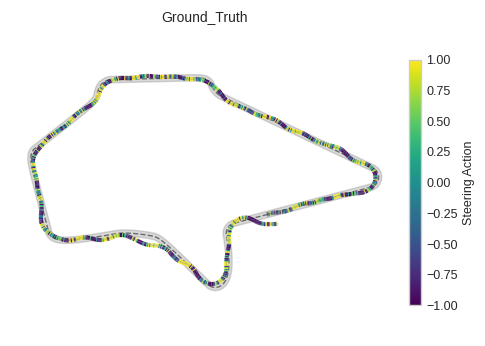

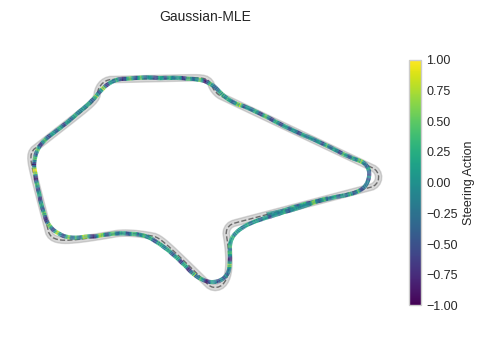

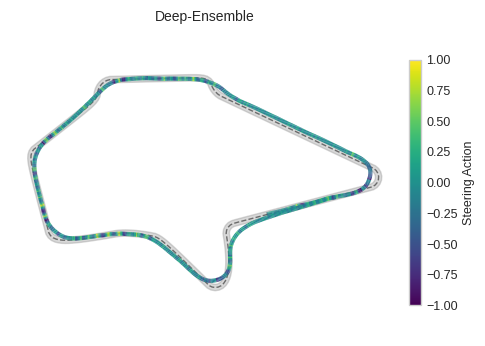

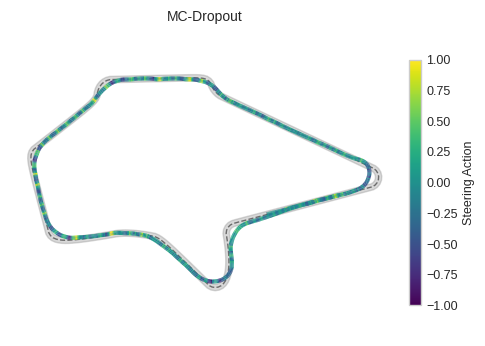

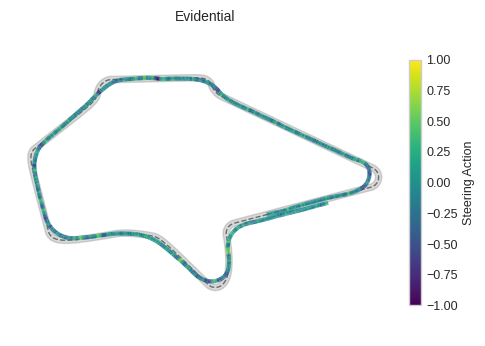

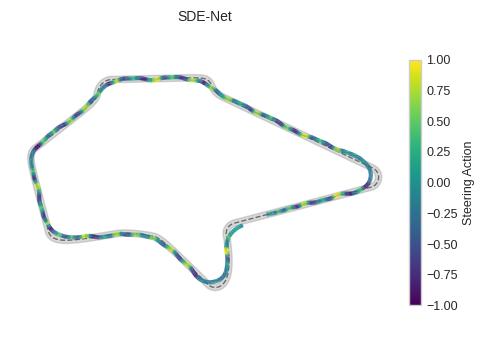

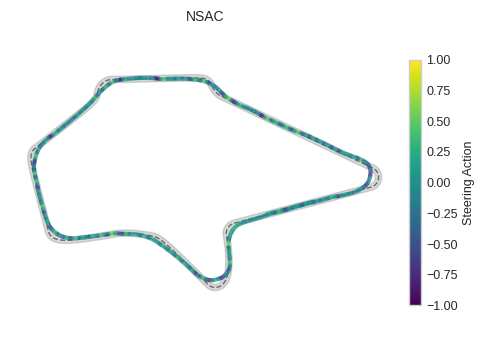

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

TRACK_DIR = "tracks"


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
})

def extract_track(df):
    return {
        "center_x": df["center_x"].values,
        "center_y": df["center_y"].values,
        "left_x": df["left_x"].values,
        "left_y": df["left_y"].values,
        "right_x": df["right_x"].values,
        "right_y": df["right_y"].values,
    }


def extract_trajectory(df, x_col, y_col, label):
    return {"x": df[x_col].values,"y": df[y_col].values,"label": label}


def plot_heatmap_line(x, y, values, cmap="viridis"):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments,cmap=cmap, norm=plt.Normalize(-1, 1))
    lc.set_array(values[:-1])
    lc.set_linewidth(3)
    plt.gca().add_collection(lc)
    return lc


def plot_scene(track, traj, actions, title):
    plt.figure(figsize=(5, 3.5))

    plt.fill(
        np.concatenate([track["left_x"], track["right_x"][::-1]]),
        np.concatenate([track["left_y"], track["right_y"][::-1]]),
        color="gray",
        alpha=0.3)
    plt.plot(track["center_x"], track["center_y"],"--", color="black",linewidth=1,alpha=0.5)

    x, y = traj["x"], traj["y"]

    n = min(len(x), len(actions))
    x, y, actions = x[:n], y[:n], actions[:n]

    if n > 1:
        lc = plot_heatmap_line(x, y, actions)
        plt.colorbar(lc, label="Steering Action", shrink=0.8, aspect=20, pad=0.02)

    plt.plot(x, y, alpha=0.2)

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.axis("equal")
    plt.title(title)
    plt.tight_layout()
    plt.show()


MODEL_LIST = ["Ground_Truth", "Gaussian-MLE", "Deep-Ensemble", "MC-Dropout", "Evidential", "SDE-Net", "NSAC"]
track = None

for name in MODEL_LIST:
    df = pd.read_csv(f"{TRACK_DIR}/record_{name}.csv")

    if name == "Ground_Truth":
        track = extract_track(df)

    traj = extract_trajectory(df, f"{name}_x", f"{name}_y", name)
    actions = df[f"{name}_action"].values

    plot_scene(track, traj, actions, name)

Saliency maps

2026-05-18 19:41:46.311240: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-18 19:41:46.323172: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779104506.336987   11507 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779104506.341004   11507 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-18 19:41:46.354841: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

frame_input shape: (1, 4, 84, 84, 1)
Processing NSAC...


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'ou_wrap', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Processing Gaussian-MLE...


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 48 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Processing Deep-Ensemble...
Processing MC-Dropout...
Processing Evidential...


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 90 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Processing SDE-Net...


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


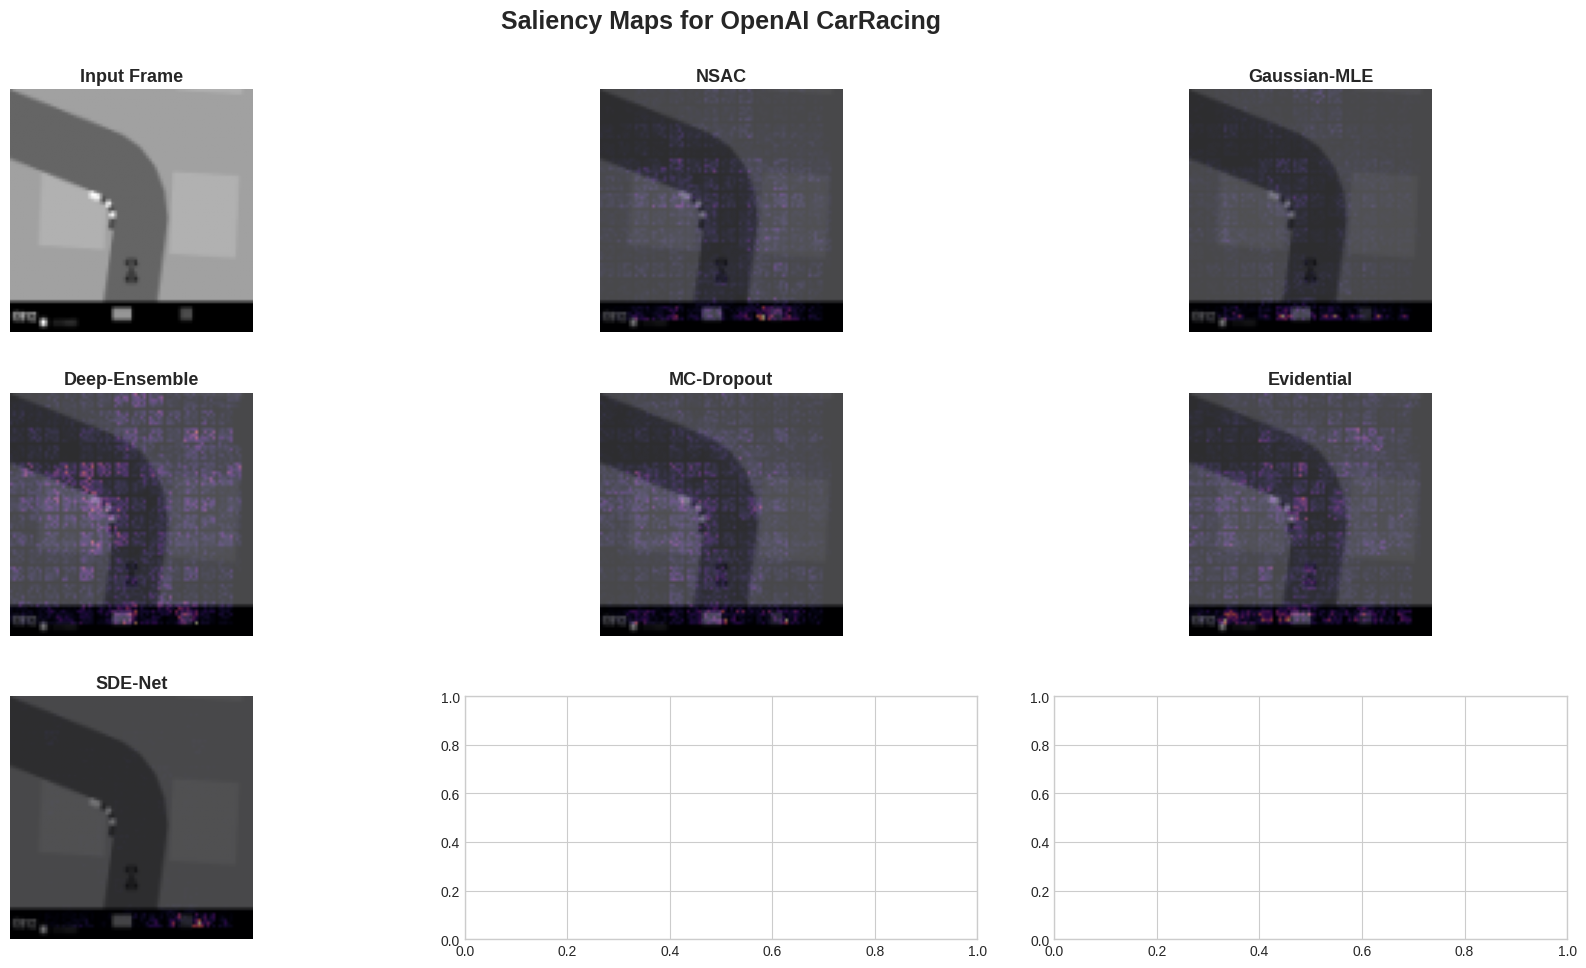

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Flatten, TimeDistributed, Conv2D, GlobalMaxPooling1D, BatchNormalization, MaxPool2D
from tensorflow.keras.models import Model

from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.atari_wrappers import WarpFrame
from stable_baselines3.common.vec_env import VecFrameStack, VecTransposeImage, VecMonitor
import tensorflow as tf
from baseline_cells import ContiFormer, ODEformer, OTTransformer
from neuronal_attention_circuit import NAC
from ouwrap import OUWrap

from ouwrap import OUWrap
from losses import NSACLoss, NLL
from neuronal_attention_circuit import NAC
from neuronal_stochastic_attention_circuit import NSAC
from metrics import compute_crps, compute_ece, compute_auroc



from baselines import DeepEnsemble, MC_dropout, Evidential, GMLE, SDE_Net
from evidential_deep_learning.layers import DenseNormalGamma
from evidential_deep_learning.losses import EvidentialRegression

import pickle
import math
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Flatten, TimeDistributed,
    Conv2D, MaxPool2D, BatchNormalization,
    GlobalMaxPooling1D
)

from baseline_cells import ODEformer, ContiFormer, OTTransformer
from neuronal_attention_circuit import NAC
from ouwrap import OUWrap


# ---------------- Paths ----------------
base_model_name = "CarRacing"
WEIGHTS_DIR = "closed_loop_weights"
PLOT_DIR = "plots"


# ---------------- Load Data ----------------
with open("/home/ustc15/research/idea10/CarRacing/data.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["observations"])
y = np.array(data["actions"])
y = np.squeeze(y, axis=1)
X = np.squeeze(X, axis=1)
X_events = X[..., np.newaxis].astype("float32") / 255.0

# ---------------- Model Builder ----------------
def _build_nsac():
    def model_fn(input_shape=(None, 84, 84, 1)):
        inp = Input(shape=input_shape)

        x = TimeDistributed(Conv2D(32,(5,5),activation='relu',strides=3))(inp)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(48,(3,3),activation='relu',strides=2))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(64,(2,2),activation='relu'))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(BatchNormalization())(x)
        x = TimeDistributed(Flatten())(x)
        mu,log_std = OUWrap(
            NAC(d_model=64,num_heads=16, sparsity=0.7, topk=8),
            bn_mean=0.0,
            bn_std=0.0001,
            output_dim=3,
            activation='tanh',
            return_sequences=False
            )(x)
        return Model(inp, [mu,log_std])
    model = NSAC(stochastic_model_fn=model_fn(),mc_samples=3, ood_mean=0.0, ood_std=0.0001)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3), loss=NSACLoss())
    return model

def _build_mle():
    def model_fn(input_shape=(None, 84, 84, 1)):
        inp = Input(shape=input_shape)
        x = TimeDistributed(Conv2D(32,(5,5),activation='relu',strides=3))(inp)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(48,(3,3),activation='relu',strides=2))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(64,(2,2),activation='relu'))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(BatchNormalization())(x)
        x = TimeDistributed(Flatten())(x)
        x = NAC(
            d_model=64,
            num_heads=16,
            mode='exact',
            sparsity=0.5,
            topk=16,
            activation='relu',
            return_sequences=False
        )(x)
        mu = tf.keras.layers.Dense(3)(x)
        log_std = tf.keras.layers.Dense(3)(x)
        return tf.keras.Model(inp, [mu,log_std])
    model = GMLE(model_fn())
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3), loss=NLL())
    return model

def _build_deep_ensemble():
    def model_fn(input_shape=(None, 84, 84, 1)):
        inp = Input(shape=input_shape)
        x = TimeDistributed(Conv2D(32,(5,5),activation='relu',strides=3))(inp)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(48,(3,3),activation='relu',strides=2))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(64,(2,2),activation='relu'))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(BatchNormalization())(x)
        x = TimeDistributed(Flatten())(x)
        x = NAC(
            d_model=64,
            num_heads=16,
            mode='exact',
            sparsity=0.5,
            topk=16,
            activation='relu',
            return_sequences=False
        )(x)
        mu = tf.keras.layers.Dense(3)(x)
        log_std = tf.keras.layers.Dense(3)(x)
        return tf.keras.Model(inp, [mu,log_std])
    model = DeepEnsemble(model_fn=model_fn(), num_models=3)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3), loss=NLL())
    return model

def _build_mc_dropout():
    def model_fn(input_shape=(None, 84, 84, 1),dropout_rate=0.1):
        inp = Input(shape=input_shape)
        x = TimeDistributed(Conv2D(32,(5,5),activation='relu',strides=3))(inp)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(48,(3,3),activation='relu',strides=2))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(64,(2,2),activation='relu'))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(BatchNormalization())(x)
        x = TimeDistributed(Flatten())(x)
        x = NAC(
            d_model=64,
            num_heads=16,
            mode='exact',
            sparsity=0.5,
            topk=16,
            activation='relu',
            return_sequences=False
        )(x)
        mu = tf.keras.layers.Dense(3)(x)
        log_std = tf.keras.layers.Dense(3)(x)
        return tf.keras.Model(inp, [mu,log_std])
    model = MC_dropout(model_fn=model_fn(),mc_samples=5)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3), loss=NLL())
    return model

def _build_evidential():
    def model_fn(input_shape=(None, 84, 84, 1)):
        inp = Input(shape=input_shape)
        x = TimeDistributed(Conv2D(32,(5,5),activation='relu',strides=3))(inp)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(48,(3,3),activation='relu',strides=2))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(Conv2D(64,(2,2),activation='relu'))(x)
        x = TimeDistributed(MaxPool2D(2,2))(x)
        x = TimeDistributed(BatchNormalization())(x)
        x = TimeDistributed(Flatten())(x)
        x = NAC(
            d_model=64,
            num_heads=16,
            mode='exact',
            sparsity=0.5,
            topk=16,
            activation='relu',
            return_sequences=False
        )(x)
        output = DenseNormalGamma(3)(x)
        return tf.keras.Model(inp, output)
    model = Evidential(model_fn(),lambda_reg=0.5)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3), loss=EvidentialRegression)
    return model

class CNN_SDE_Wrapper(tf.keras.Model):
    def __init__(self, sde_net: SDE_Net):
        super().__init__()
        self.cnn = self._build_cnn()
        self.sde_net = sde_net
        self.optimizer_cnn = tf.keras.optimizers.AdamW(1e-3)
        self.mc_samples = 10

    def _build_cnn(self):
        return tf.keras.Sequential([
            TimeDistributed(Conv2D(32, (5,5), activation='relu', strides=3)),
            TimeDistributed(MaxPool2D(2, 2)),
            TimeDistributed(Conv2D(48, (3,3), activation='relu', strides=2)),
            TimeDistributed(MaxPool2D(2, 2)),
            TimeDistributed(Conv2D(64, (2,2), activation='relu')),
            TimeDistributed(MaxPool2D(2, 2)),
            TimeDistributed(BatchNormalization()),
            TimeDistributed(Flatten()),
        ])

    def _cnn_to_sde(self, x, training_diffusion=False):
        features = self.cnn(x)                      
        shape    = tf.shape(features)
        flat     = tf.reshape(features, (shape[0] * shape[1], features.shape[-1]))
        return self.sde_net(flat, training_diffusion=training_diffusion)

    def call(self, inputs, training_diffusion=False):
        return self._cnn_to_sde(inputs, training_diffusion)
    
    def compile(self, optimizer_drift, optimizer_fc, optimizer_dsl, optimizer_diffusion, loss, **kwargs):
        super().compile(**kwargs)  
        self.sde_net.compile(
            optimizer_drift=optimizer_drift,
            optimizer_fc=optimizer_fc,
            optimizer_dsl=optimizer_dsl,
            optimizer_diffusion=optimizer_diffusion,
            loss=loss,
        )

    def train_step(self, data):
        x, y = data
        x = tf.cast(x, tf.float32)
        y = tf.cast(y, tf.float32)
        with tf.GradientTape() as tape:
            features  = self.cnn(x, training=True)   
            last_feat = features[:, -1, :]
            mean, sigma = self.sde_net(last_feat, training_diffusion=False)
            nll = self.sde_net.loss_fn(y, [mean, sigma])

        cnn_grad = [tf.clip_by_norm(g, 100)
                    for g in tape.gradient(nll, self.cnn.trainable_variables)]
        self.optimizer_cnn.apply_gradients(zip(cnn_grad, self.cnn.trainable_variables))
        last_feat_detached = tf.stop_gradient(features[:, -1, :])
        sde_metrics = self.sde_net.train_step((last_feat_detached, y))
        return sde_metrics

    def test_step(self, data):
        x, y      = data
        features  = self.cnn(tf.cast(x, tf.float32), training=False)
        last_feat = features[:, -1, :]
        return self.sde_net.test_step((last_feat, tf.cast(y, tf.float32)))
    
    def calculate_uncertainty(self, X):
        X = tf.cast(X, tf.float32)
        means, variances = [], []

        for _ in range(self.mc_samples):
            mean, sigma = self.call(X, training_diffusion=False)
            means.append(mean.numpy())
            variances.append((sigma ** 2).numpy())

        means = np.stack(means, axis=0)         # [T, N, 1]
        variances = np.stack(variances, axis=0)         # [T, N, 1]

        mean_pred = np.mean(means, axis=0)
        epistemic_unc = np.var(means, axis=0)
        aleatoric_unc = np.mean(variances, axis=0)
        total_uncertainty = epistemic_unc + aleatoric_unc

        return mean_pred, aleatoric_unc, epistemic_unc, total_uncertainty

    def predict_with_uncertainty(self, X):
        mean_pred, aleatoric, epistemic, _ = self.calculate_uncertainty(X)
        return mean_pred, aleatoric, epistemic

    def comprehensive_evaluate(self, X_test, y_test):
        X_test = tf.cast(X_test, tf.float32)
        y_test = tf.cast(y_test, tf.float32)

        mean_pred, aleatoric, epistemic, total_uncertainty = self.calculate_uncertainty(X_test)
        seq_len = X_test.shape[1]
        mean_pred_last = mean_pred[seq_len-1::seq_len]  # shape [batch, output_dim]

        variance = tf.clip_by_value(total_uncertainty, 1e-6, 1e6)
        variance = variance[seq_len-1::seq_len]  # shape [batch, output_dim]

        results = super().evaluate(
            X_test,
            y_test,
            return_dict=True,
            verbose=0
        )
        nll = float(results["loss"])
        mse = tf.reduce_mean(tf.square(y_test - mean_pred_last))
        predictive_std = tf.sqrt(variance)

        return (mean_pred_last, predictive_std.numpy(), nll, mse.numpy())

    def get_config(self):
        config = super().get_config()
        config.update({
            "sde_net": self.sde_net.get_config(),
        })
        return config
    def from_config(cls, config):
        model = tf.keras.utils.deserialize_keras_object(config.pop("model"))
        return cls(model_fn=model, **config)
    

def _build_sde_net():
    sde = SDE_Net(input_dim=64, output_dim=3, hidden_dim=32, layer_depth=5)
    model = CNN_SDE_Wrapper(sde)

    model.compile(
        optimizer_drift=tf.keras.optimizers.AdamW(1e-3),
        optimizer_fc=tf.keras.optimizers.AdamW(1e-3),
        optimizer_dsl=tf.keras.optimizers.AdamW(1e-3),
        optimizer_diffusion=tf.keras.optimizers.AdamW(1e-4),
        loss=NLL(),
    )
    dummy_input = tf.zeros((1, 1, 84, 84, 1))  
    _ = model(dummy_input, training_diffusion=False)
    return model


# ---------------- Models ----------------
model_names = [
    "NSAC",
    "Gaussian-MLE",
    "Deep-Ensemble",
    "MC-Dropout",
    "Evidential",
    "SDE-Net",
]


# ---------------- Sample ----------------
sample_idx = 10000
target_class = np.argmax(y[sample_idx])

original_image = X_events[sample_idx]

frame_input = tf.convert_to_tensor(
    X_events[sample_idx:sample_idx+1],
    dtype=tf.float32
)

display_frame = original_image[-1, :, :, 0]

print("frame_input shape:", frame_input.shape)
gradcams = []


# ---------------- Compute Saliency ----------------
for name in model_names:

    print(f"Processing {name}...")

    if name == "NSAC":
        model = _build_nsac()
    elif name == "Gaussian-MLE":
        model = _build_mle()
    elif name == "Deep-Ensemble":
        model = _build_deep_ensemble()
    elif name == "MC-Dropout":
        model = _build_mc_dropout()
    elif name == "Evidential":
        model = _build_evidential()
    elif name == "SDE-Net":
        model = _build_sde_net()
    else: 
        pass

    model.load_weights(f"{WEIGHTS_DIR}/CarRacing_{name}.keras")

    with tf.GradientTape() as tape:

        tape.watch(frame_input)

        output = model(frame_input)
        # Evidential model
        if name == "Evidential":
            mu = output[..., :3]
            loss = mu[:, target_class]

        # Standard Gaussian models
        else:
            if isinstance(output, (list, tuple)):
                mu = output[0]
            else:
                mu = output

            loss = mu[:, target_class]

    grads = tape.gradient(loss, frame_input)

    saliency = tf.abs(grads[0])       # (4,84,84,1)
    saliency = tf.squeeze(saliency, -1)
    saliency = tf.reduce_max(saliency, axis=0)

    saliency /= tf.reduce_max(saliency) + 1e-8

    gradcams.append(saliency.numpy())


# ---------------- Plot ----------------
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 13
})

fig, axes = plt.subplots(3, 3, figsize=(18, 10))

fig.suptitle(
    "Saliency Maps for OpenAI CarRacing",
    fontsize=18,
    fontweight="bold"
)

axes = axes.ravel()


# Input frame
axes[0].imshow(display_frame, cmap="gray")
axes[0].set_title("Input Frame", fontweight="bold")
axes[0].axis("off")


# Saliency overlays
for i, saliency in enumerate(gradcams):

    axes[i+1].imshow(display_frame, cmap="gray")

    axes[i+1].imshow(
        saliency,
        cmap="magma",
        alpha=0.55,
        interpolation="bilinear"
    )

    axes[i+1].set_title(
        model_names[i],
        fontweight="bold"
    )

    axes[i+1].axis("off")


plt.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.90,
    bottom=0.05,
    wspace=0.15,
    hspace=0.25
)

plt.savefig(
    f"{PLOT_DIR}/OpenAI_saliencymap.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Noise Analysis

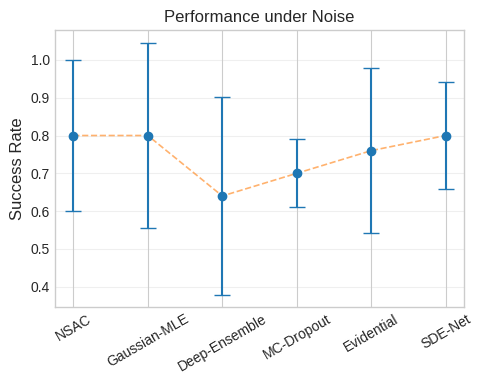

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 1.2,
    "lines.markersize": 6,
})

df = pd.read_csv("tracks/loop_car.csv")

plt.figure(figsize=(5, 4))

plt.errorbar(
    df["model"],
    df["success_mean"],
    yerr=df["success_std"],
    fmt='o',           # marker style
    capsize=6,         # little caps on error bars
    elinewidth=1.5
)

# Optional: connect points for readability
plt.plot(df["model"], df["success_mean"], linestyle='--', alpha=0.6)

# plt.xlabel("Model")
plt.ylabel("Success Rate")
plt.title("Performance under Noise")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("carloop_mean_std.png")
plt.show()